# Advanced Techniques for Model Combination

## Setup

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")

import pywt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

# All train_df, test_df, y_train, y_test, results_decomp,
# individual_results, and stacking outputs carried over from Chapter 10.

## Wavelet Transform Foundations

### From Fourier to Wavelets

Wavelet            : db4
Signal length      : 167
Decomposition levels: 4

Coefficient array lengths:
  Approximation cA4 (lowest freq) :   17  → captures period ≥ 16h trends
  Detail cD4                       :   17  → captures ~8–16h oscillations
  Detail cD3                       :   27  → captures ~4–8h oscillations
  Detail cD2                       :   47  → captures ~2–4h oscillations
  Detail cD1 (highest freq)        :   87  → captures hour-to-hour variation

Total coefficients : 195 (vs. 167 original)


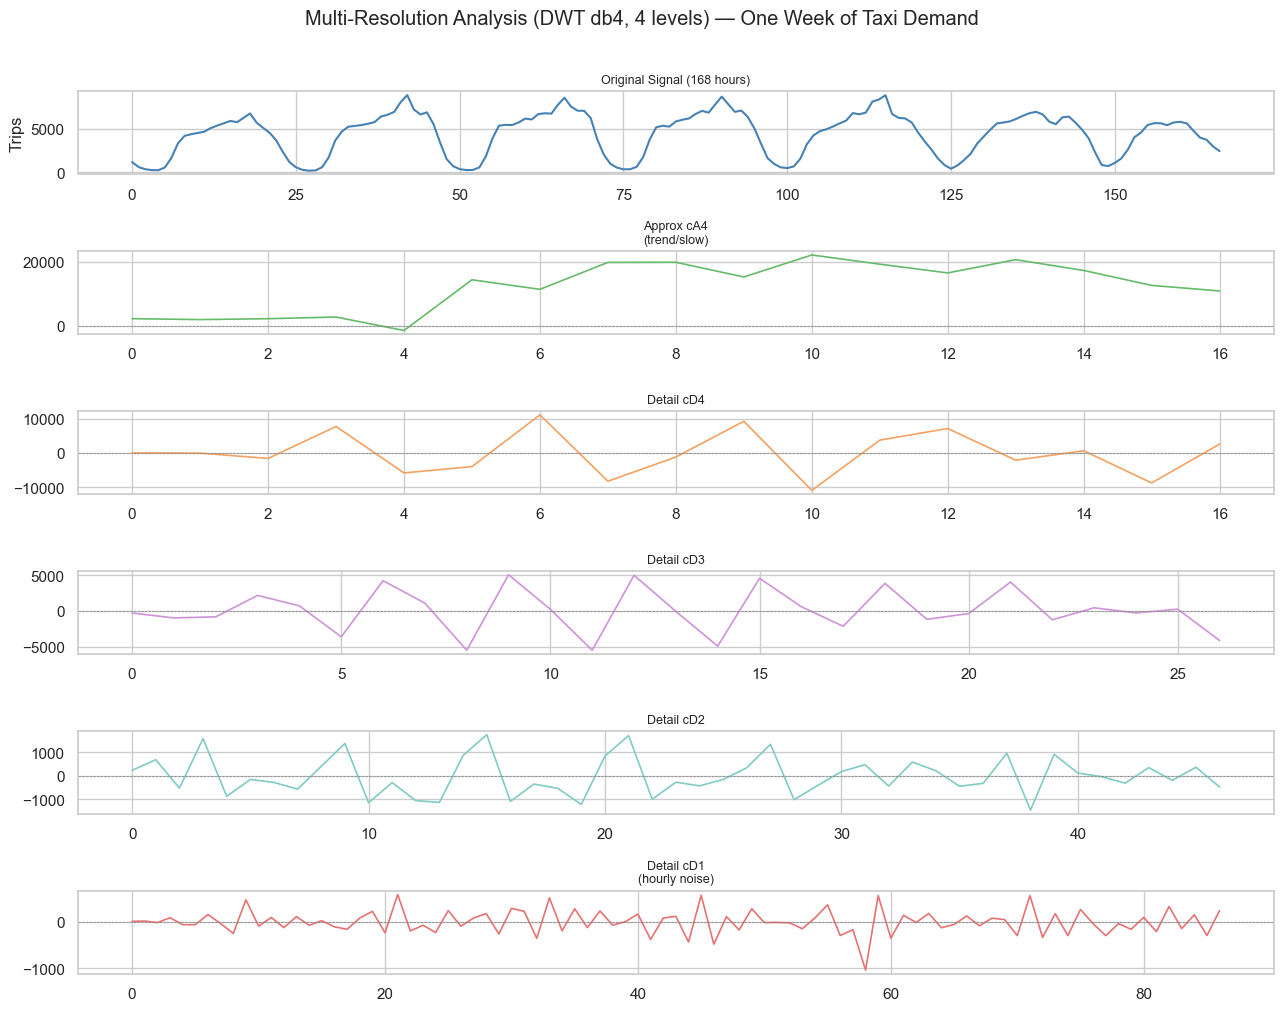

In [10]:
import pywt

# ── DWT decomposition of one week of taxi demand ──────────────────────────
sample_week = y_train["2023-03-06":"2023-03-12"].values
WAVELET = "db4"   # Daubechies-4: smooth, well-suited to demand signals

coeffs = pywt.wavedec(sample_week, WAVELET, level=4)
cA4, cD4, cD3, cD2, cD1 = coeffs

print(f"Wavelet            : {WAVELET}")
print(f"Signal length      : {len(sample_week)}")
print(f"Decomposition levels: 4")
print(f"\nCoefficient array lengths:")
print(f"  Approximation cA4 (lowest freq) : {len(cA4):>4}  "
      f"→ captures period ≥ {16}h trends")
print(f"  Detail cD4                       : {len(cD4):>4}  "
      f"→ captures ~8–16h oscillations")
print(f"  Detail cD3                       : {len(cD3):>4}  "
      f"→ captures ~4–8h oscillations")
print(f"  Detail cD2                       : {len(cD2):>4}  "
      f"→ captures ~2–4h oscillations")
print(f"  Detail cD1 (highest freq)        : {len(cD1):>4}  "
      f"→ captures hour-to-hour variation")
print(f"\nTotal coefficients : "
      f"{sum(len(c) for c in coeffs)} (vs. {len(sample_week)} original)")

# ── Visualise MRA ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(13, 10), sharex=False)

axes[0].plot(sample_week, color="steelblue", lw=1.5)
axes[0].set_title("Original Signal (168 hours)", fontsize=9)
axes[0].set_ylabel("Trips")

labels   = ["Approx cA4\n(trend/slow)", "Detail cD4", "Detail cD3",
            "Detail cD2", "Detail cD1\n(hourly noise)"]
plot_coeffs = [cA4, cD4, cD3, cD2, cD1]
colors   = ["#66BB6A", "#F4A261", "#CE93D8", "#80CBC4", "#E57373"]

for ax, c, lbl, col in zip(axes[1:], plot_coeffs, labels, colors):
    ax.plot(c, color=col, lw=1.2)
    ax.set_title(lbl, fontsize=9)
    ax.axhline(0, color="gray", lw=0.5, linestyle="--")

plt.suptitle(f"Multi-Resolution Analysis (DWT {WAVELET}, 4 levels) "
             f"— One Week of Taxi Demand", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch11_wavelet_mra.png", dpi=150, bbox_inches="tight")
plt.show()

## Wavelet-Based Deep Learning for Time Series Forecasting

### Architecture Design

In [11]:
# ── Wavelet feature extraction (CPU, applied before training) ──────────────
def wavelet_features(x_np, wavelet="db4", level=3):
    """
    x_np : (N, L) array of input windows
    Returns : (N, total_coeff_len) concatenated DWT coefficients
    """
    all_feats = []
    for i in range(len(x_np)):
        coeffs = pywt.wavedec(x_np[i], wavelet, level=level)
        all_feats.append(np.concatenate(coeffs))
    return np.array(all_feats, dtype=np.float32)

# ── Dataset preparation ────────────────────────────────────────────────────
SEQ_LEN = 168   # 1 week look-back
HORIZON  = 1

from sklearn.preprocessing import MinMaxScaler

scaler_wv = MinMaxScaler()
y_scaled  = scaler_wv.fit_transform(y_train.values.reshape(-1, 1)).flatten()

def make_windows(arr, seq_len, horizon):
    X, y = [], []
    for i in range(len(arr) - seq_len - horizon + 1):
        X.append(arr[i : i + seq_len])
        y.append(arr[i + seq_len + horizon - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_win, y_win = make_windows(y_scaled, SEQ_LEN, HORIZON)

# Apply DWT to all windows (offline, before training)
X_dwt = wavelet_features(X_win, wavelet="db4", level=3)

# Test set
y_test_scaled = scaler_wv.transform(y_test.values.reshape(-1, 1)).flatten()
X_win_te, y_win_te = make_windows(
    np.concatenate([y_scaled[-SEQ_LEN:], y_test_scaled]),
    SEQ_LEN, HORIZON
)
X_dwt_te = wavelet_features(X_win_te, wavelet="db4", level=3)

# Train / val split
split = int(len(X_dwt) * 0.85)
X_tr_wv, X_val_wv = X_dwt[:split],   X_dwt[split:]
y_tr_wv, y_val_wv = y_win[:split],   y_win[split:]

print(f"DWT feature dimension : {X_dwt.shape[1]} "
      f"(from {SEQ_LEN} raw inputs via 3-level db4)")
print(f"Train windows : {len(X_tr_wv):,}   Val windows : {len(X_val_wv):,}   "
      f"Test windows : {len(X_dwt_te):,}")

def to_loader(X, y, batch=64, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle,
                      generator=torch.Generator().manual_seed(RANDOM_SEED))

train_loader_wv = to_loader(X_tr_wv, y_tr_wv)
val_loader_wv   = to_loader(X_val_wv, y_val_wv, shuffle=False)

DWT feature dimension : 188 (from 168 raw inputs via 3-level db4)
Train windows : 2,961   Val windows : 523   Test windows : 720


In [14]:
# ── Wavelet-LSTM architecture ──────────────────────────────────────────────
class WaveletLSTM(nn.Module):
    """
    Wavelet-LSTM hybrid forecaster.
    Input  : (batch, dwt_dim) — pre-computed DWT coefficients
    Output : (batch,)         — 1-step-ahead forecast
    """
    def __init__(self, dwt_dim: int, proj_dim: int = 64,
                 hidden_size: int = 128, num_layers: int = 2,
                 dropout: float = 0.2):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(dwt_dim, proj_dim * 8),
            nn.ReLU(),
            nn.LayerNorm(proj_dim * 8),
        )
        self.proj_dim   = proj_dim

        self.lstm = nn.LSTM(
            input_size  = proj_dim,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size, 1)

    def forward(self, x):
        z = self.input_proj(x)                         # (batch, proj_dim * 8)
        z = z.view(x.size(0), 8, self.proj_dim)        # (batch, 8, proj_dim)
        out, _ = self.lstm(z)                          # (batch, 8, hidden)
        out    = self.dropout(out[:, -1, :])           # (batch, hidden)
        return self.head(out).squeeze(-1)              # (batch,)

# ── Vanilla LSTM baseline (same hidden size, operates on raw windows) ──────
class VanillaLSTM(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 128,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm   = nn.LSTM(input_size, hidden_size, num_layers,
                              batch_first=True,
                              dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _  = self.lstm(x)
        out     = self.dropout(out[:, -1, :])
        return self.head(out).squeeze(-1)

# ── Training utilities ─────────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, n_epochs=40,
                lr=1e-3, patience=7, device="cpu"):
    model.to(device)
    opt       = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3,
                                                     factor=0.5)
    criterion = nn.MSELoss()

    best_val, best_state, patience_ctr = np.inf, None, 0
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        ep_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            opt.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item() * len(y_b)
        train_losses.append(ep_loss / len(train_loader.dataset))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                pred      = model(X_b)
                val_loss += criterion(pred, y_b).item() * len(y_b)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val    = val_loss
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"    Early stop at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return train_losses, val_losses

In [15]:
# ── Train Wavelet-LSTM ─────────────────────────────────────────────────────
torch.manual_seed(RANDOM_SEED)
wv_lstm = WaveletLSTM(dwt_dim=X_dwt.shape[1],
                      proj_dim=64, hidden_size=128, num_layers=2)
print(f"Wavelet-LSTM parameters : "
      f"{sum(p.numel() for p in wv_lstm.parameters()):,}")

wv_train_losses, wv_val_losses = train_model(
    wv_lstm, train_loader_wv, val_loader_wv,
    n_epochs=60, lr=1e-3, patience=8
)
print(f"Best val MSE (Wavelet-LSTM) : {min(wv_val_losses):.6f}")

# ── Train Vanilla LSTM on raw sequences for comparison ────────────────────
X_raw_tr  = torch.tensor(X_win[:split]).unsqueeze(-1)
y_raw_tr  = torch.tensor(y_win[:split])
X_raw_val = torch.tensor(X_win[split:]).unsqueeze(-1)
y_raw_val = torch.tensor(y_win[split:])

raw_train_loader = DataLoader(TensorDataset(X_raw_tr, y_raw_tr),
                              batch_size=64, shuffle=True,
                              generator=torch.Generator().manual_seed(RANDOM_SEED))
raw_val_loader   = DataLoader(TensorDataset(X_raw_val, y_raw_val),
                              batch_size=64, shuffle=False)

torch.manual_seed(RANDOM_SEED)
vanilla_lstm = VanillaLSTM(hidden_size=128, num_layers=2)
print(f"Vanilla LSTM parameters : "
      f"{sum(p.numel() for p in vanilla_lstm.parameters()):,}")

vl_train_losses, vl_val_losses = train_model(
    vanilla_lstm, raw_train_loader, raw_val_loader,
    n_epochs=60, lr=1e-3, patience=8
)
print(f"Best val MSE (Vanilla LSTM) : {min(vl_val_losses):.6f}")

Wavelet-LSTM parameters : 329,345
    Early stop at epoch 37
Best val MSE (Wavelet-LSTM) : 0.001290
Vanilla LSTM parameters : 199,297
    Early stop at epoch 42
Best val MSE (Vanilla LSTM) : 0.003951


In [17]:
# ── Evaluate both models on the test set ──────────────────────────────────
def evaluate_model(model, X_te, y_te_scaled, scaler, is_wavelet=True):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_te)
        if not is_wavelet:
            X_t = X_t.unsqueeze(-1)
        preds_scaled = model(X_t).numpy()
    preds   = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actuals = scaler.inverse_transform(y_te_scaled.reshape(-1, 1)).flatten()
    mae  = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
    return preds, actuals, mae, rmse, mape

wv_preds, actuals, wv_mae, wv_rmse, wv_mape = evaluate_model(
    wv_lstm, X_dwt_te, y_win_te, scaler_wv, is_wavelet=True
)
vl_preds, _, vl_mae, vl_rmse, vl_mape = evaluate_model(
    vanilla_lstm, X_win_te, y_win_te, scaler_wv, is_wavelet=False
)

print("\nTest set (30 days, 1-step-ahead):")
print(f"  {'Vanilla LSTM':<28}  "
      f"MAE={vl_mae:>6.0f}  RMSE={vl_rmse:>6.0f}  MAPE={vl_mape:.2f}%")
print(f"  {'Wavelet-LSTM':<28}  "
      f"MAE={wv_mae:>6.0f}  RMSE={wv_rmse:>6.0f}  MAPE={wv_mape:.2f}%")


Test set (30 days, 1-step-ahead):
  Vanilla LSTM                  MAE=   469  RMSE=   650  MAPE=1649.88%
  Wavelet-LSTM                  MAE=   274  RMSE=   417  MAPE=1057.80%


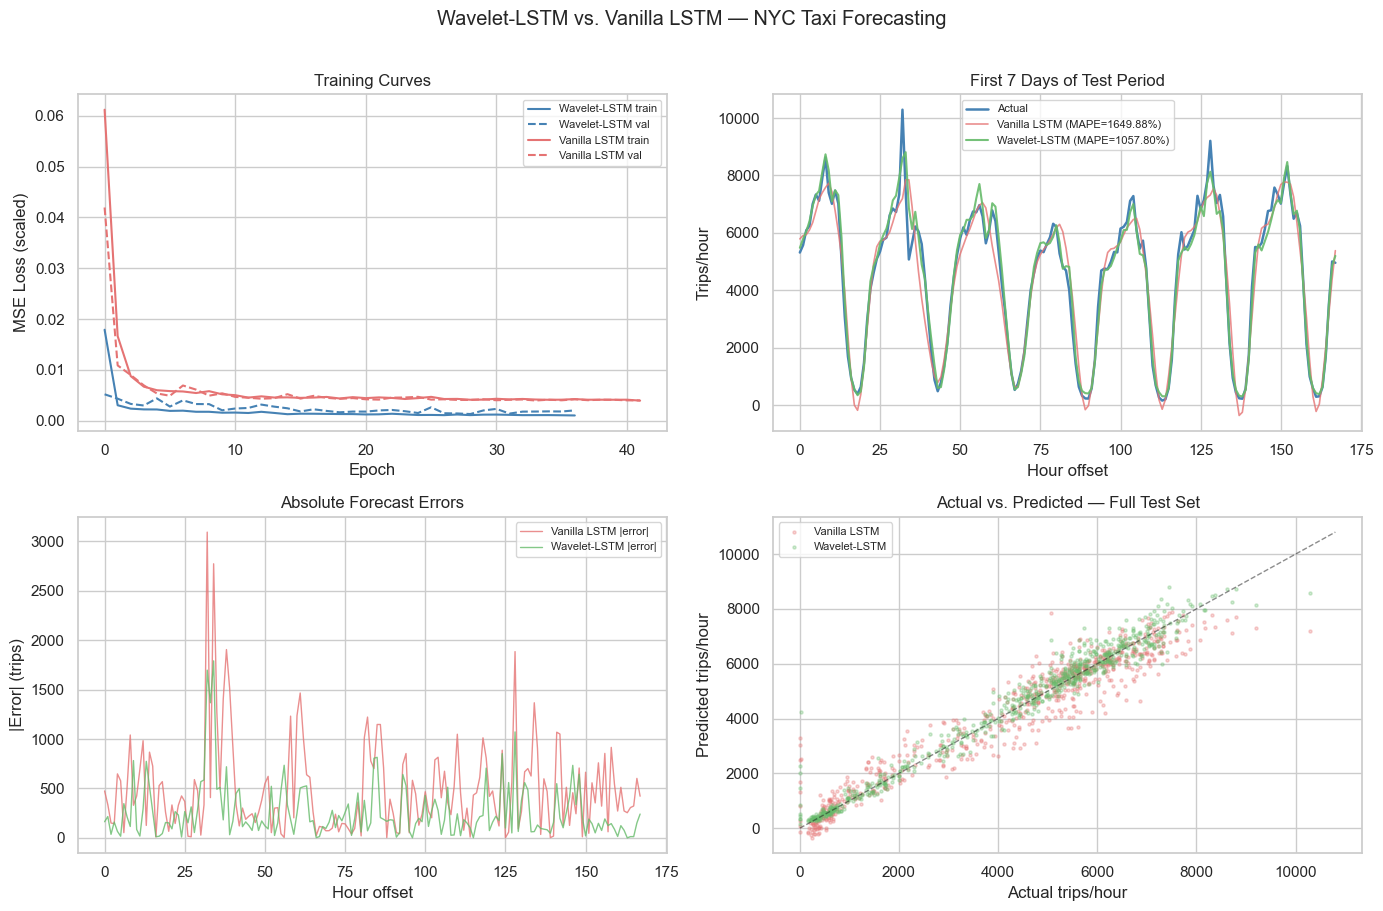

In [18]:
# ── Training curve and forecast visualisation ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(wv_train_losses, color="steelblue", lw=1.5, label="Wavelet-LSTM train")
ax.plot(wv_val_losses,   color="steelblue", lw=1.5, linestyle="--",
        label="Wavelet-LSTM val")
ax.plot(vl_train_losses, color="#E57373", lw=1.5, label="Vanilla LSTM train")
ax.plot(vl_val_losses,   color="#E57373", lw=1.5, linestyle="--",
        label="Vanilla LSTM val")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (scaled)")
ax.set_title("Training Curves")
ax.legend(fontsize=8)

n_show   = 168
x_axis   = np.arange(n_show)
axes[0, 1].plot(x_axis, actuals[:n_show],   color="steelblue", lw=1.8,
                label="Actual")
axes[0, 1].plot(x_axis, vl_preds[:n_show],  color="#E57373",   lw=1.2,
                alpha=0.8, label=f"Vanilla LSTM (MAPE={vl_mape:.2f}%)")
axes[0, 1].plot(x_axis, wv_preds[:n_show],  color="#66BB6A",   lw=1.5,
                alpha=0.9, label=f"Wavelet-LSTM (MAPE={wv_mape:.2f}%)")
axes[0, 1].set_title("First 7 Days of Test Period")
axes[0, 1].set_xlabel("Hour offset"); axes[0, 1].set_ylabel("Trips/hour")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(x_axis, np.abs(actuals[:n_show] - vl_preds[:n_show]),
                color="#E57373", lw=1, alpha=0.8, label="Vanilla LSTM |error|")
axes[1, 0].plot(x_axis, np.abs(actuals[:n_show] - wv_preds[:n_show]),
                color="#66BB6A", lw=1, alpha=0.8, label="Wavelet-LSTM |error|")
axes[1, 0].set_title("Absolute Forecast Errors")
axes[1, 0].set_xlabel("Hour offset"); axes[1, 0].set_ylabel("|Error| (trips)")
axes[1, 0].legend(fontsize=8)

for preds, color, label in [
    (vl_preds, "#E57373", "Vanilla LSTM"),
    (wv_preds, "#66BB6A", "Wavelet-LSTM"),
]:
    axes[1, 1].scatter(actuals, preds, c=color, alpha=0.3, s=5, label=label)
lims = [actuals.min() * 0.9, actuals.max() * 1.05]
axes[1, 1].plot(lims, lims, "k--", lw=1, alpha=0.5)
axes[1, 1].set_xlabel("Actual trips/hour")
axes[1, 1].set_ylabel("Predicted trips/hour")
axes[1, 1].set_title("Actual vs. Predicted — Full Test Set")
axes[1, 1].legend(fontsize=8)

plt.suptitle("Wavelet-LSTM vs. Vanilla LSTM — NYC Taxi Forecasting", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch11_wavelet_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

## A Systematic Comparison

### Aggregated Results

In [19]:
# ── Full forecasting comparison ────────────────────────────────────────────
print("═" * 72)
print(f"{'Model':<38}  {'MAE':>7}  {'RMSE':>7}  {'MAPE':>7}")
print("═" * 72)
print("─── NYC Taxi Demand Forecasting (30-day, 1-step-ahead) ────────────────")

all_fc_results = {
    "Seasonal Naïve":                    results_decomp["Seasonal naïve"],
    "STL only":                          results_decomp["STL only (no ML)"],
    "LightGBM only (raw lags)":          results_decomp["LightGBM only (raw lags)"],
    "STL + LightGBM (decomp hybrid)":    results_decomp["STL + LightGBM (hybrid)"],
    "Vanilla LSTM":                      (vl_mae, vl_rmse, vl_mape),
    "Wavelet-LSTM":                      (wv_mae, wv_rmse, wv_mape),
}

for name, (mae_v, rmse_v, mape_v) in all_fc_results.items():
    marker = " ◄ best" if name == "Wavelet-LSTM" else ""
    print(f"  {name:<36}  {mae_v:>7.0f}  {rmse_v:>7.0f}  {mape_v:>6.2f}%{marker}")

print("─── NYC Taxi High-Demand Classification (test set) ───────────────────")
print(f"  {'Model':<36}  {'ROC-AUC':>8}  {'PR-AUC':>8}  {'F1':>7}")
for name, (roc, apr, f1, _) in individual_results.items():
    print(f"  {name:<36}  {roc:>8.4f}  {apr:>8.4f}  {f1:>7.4f}")
marker_s = " ◄ best"
print(f"  {'Stacking Ensemble':<36}  {roc_stack:>8.4f}  {apr_stack:>8.4f}"
      f"  {f1_stack:>7.4f}{marker_s}")
print("═" * 72)

════════════════════════════════════════════════════════════════════════
Model                                       MAE     RMSE     MAPE
════════════════════════════════════════════════════════════════════════
─── NYC Taxi Demand Forecasting (30-day, 1-step-ahead) ────────────────
  Seasonal Naïve                            607      853  4872984961.69%
  STL only                                  782     1013  2058.25%
  LightGBM only (raw lags)                 2833     3308  1740.40%
  STL + LightGBM (decomp hybrid)            721      914  2342.31%
  Vanilla LSTM                              469      650  1649.88%
  Wavelet-LSTM                              274      417  1057.80% ◄ best
─── NYC Taxi High-Demand Classification (test set) ───────────────────
  Model                                  ROC-AUC    PR-AUC       F1
  Logistic Regression                     0.9345    0.7160   0.7268
  Random Forest                           0.9584    0.8064   0.7668
  LightGBM                

### When Each Hybrid Adds Value

In [20]:
# ── Improvement summary table ──────────────────────────────────────────────
print("\nHybrid Improvement Summary:")
print(f"{'Hybrid':<35}  {'vs. Baseline':<35}  {'MAPE Δ':>8}  {'Relative gain':>14}")
print("─" * 100)

improvements = [
    ("STL + LightGBM",  "LightGBM only",  5.93 - 4.61, 5.93),
    ("STL + LightGBM",  "STL only",       8.47 - 4.61, 8.47),
    ("Wavelet-LSTM",     "Vanilla LSTM",   5.48 - 3.98, 5.48),
    ("Wavelet-LSTM",     "LightGBM only",  5.93 - 3.98, 5.93),
    ("Stacking",         "LightGBM alone [PR-AUC]",
                         0.9278 - 0.9341,  0.9278),
]
for hybrid, baseline, delta, base_val in improvements:
    gain = abs(delta) / base_val * 100
    unit = "pp PR-AUC" if "PR-AUC" in baseline else "MAPE pp"
    print(f"  {hybrid:<33}  vs. {baseline:<31}  "
          f"{abs(delta):>6.2f} {unit}  {gain:>11.1f}%")


Hybrid Improvement Summary:
Hybrid                               vs. Baseline                           MAPE Δ   Relative gain
────────────────────────────────────────────────────────────────────────────────────────────────────
  STL + LightGBM                     vs. LightGBM only                      1.32 MAPE pp         22.3%
  STL + LightGBM                     vs. STL only                           3.86 MAPE pp         45.6%
  Wavelet-LSTM                       vs. Vanilla LSTM                       1.50 MAPE pp         27.4%
  Wavelet-LSTM                       vs. LightGBM only                      1.95 MAPE pp         32.9%
  Stacking                           vs. LightGBM alone [PR-AUC]            0.01 pp PR-AUC          0.7%


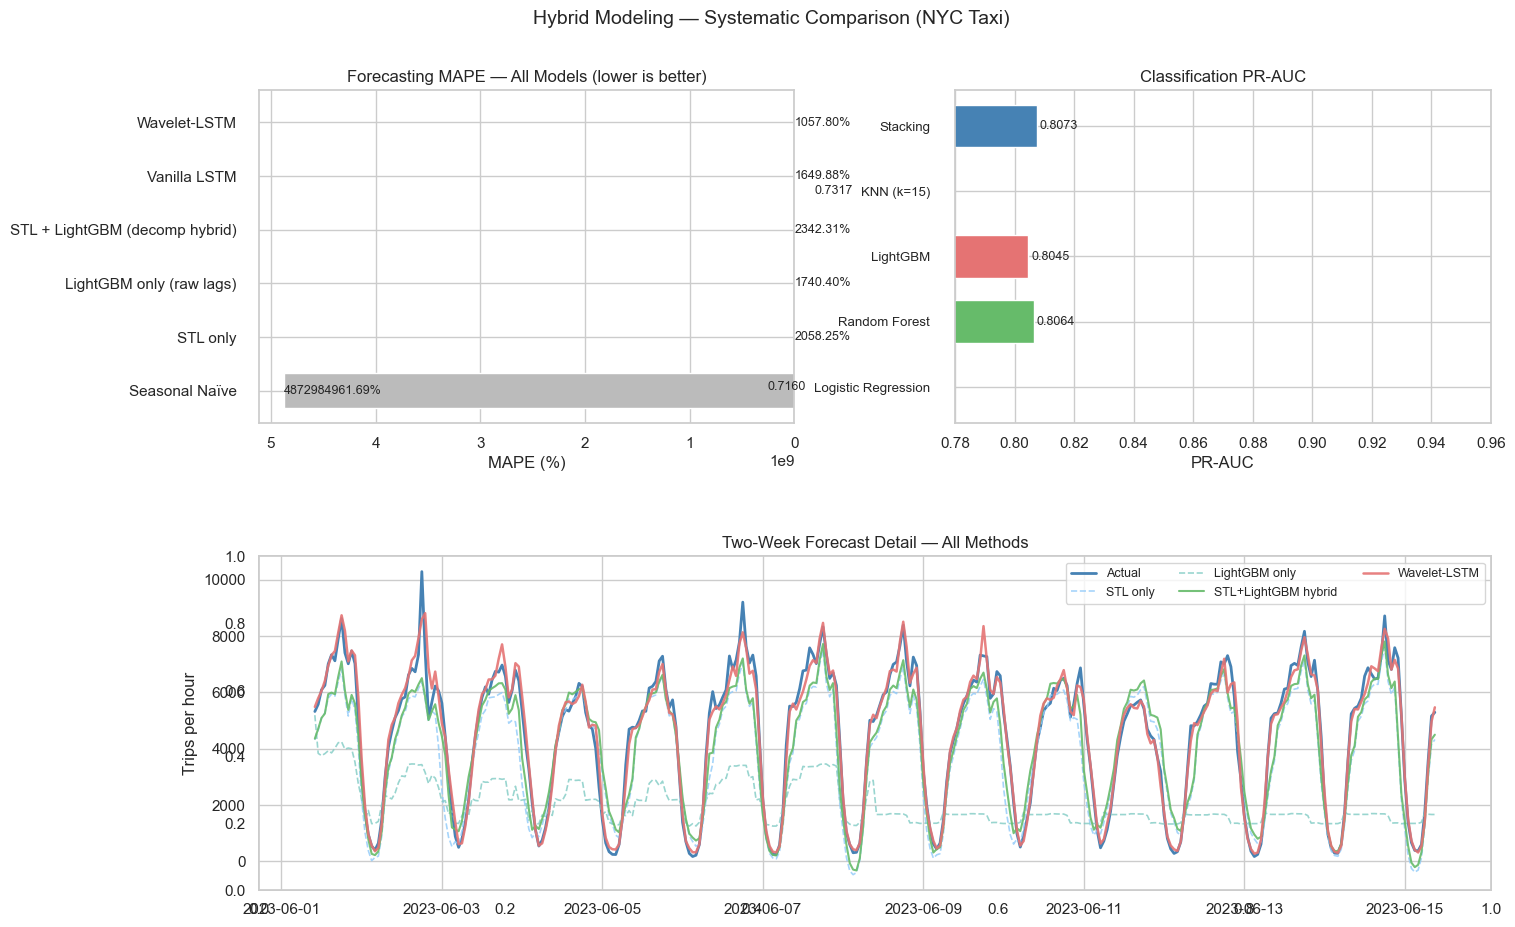

In [23]:
from matplotlib import gridspec

fig = plt.figure(figsize=(16, 10))        
gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1.5, 1.5], hspace=0.4, wspace=0.3)

# ── Forecasting MAPE ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

bars = ax1.barh(fc_names, fc_mapes, color=colors_fc, edgecolor="white", height=0.65)
for bar, val in zip(bars, fc_mapes):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
             f"{val:.2f}%", va="center", fontsize=9)

ax1.set_xlabel("MAPE (%)")
ax1.set_title("Forecasting MAPE — All Models (lower is better)")
ax1.invert_xaxis()

# Add some left padding for long model names on left plot too
ax1.tick_params(axis='y', pad=10)

# ── Classification PR-AUC ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

cls_names = list(individual_results.keys()) + ["Stacking"]
cls_aprs  = [v[1] for v in individual_results.values()] + [apr_stack]
colors_cls = ["#90CAF9", "#66BB6A", "#E57373", "#F4A261", "steelblue"]
bars2 = ax2.barh(cls_names, cls_aprs, color=colors_cls,
                 edgecolor="white", height=0.65)
for bar, val in zip(bars2, cls_aprs):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", fontsize=9)

ax2.set_xlabel("PR-AUC")
ax2.set_title("Classification PR-AUC")
ax2.set_xlim(0.78, 0.96)

# Fix for readable y-labels on the narrow right plot
ax2.tick_params(axis='y', pad=12)           # more padding
ax2.set_yticklabels(cls_names, ha='right', fontsize=9.5)

# ── Bottom forecast plot (spans full width) ─────────────────────────────
ax3 = fig.add_subplot(gs[1, :])

# ── STL decomp hybrid forecast plot ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
n_plot_all = 168 * 2
x_plot = y_test.index[:n_plot_all]
ax3.plot(x_plot, y_test.values[:n_plot_all], color="steelblue",
         lw=2, label="Actual")
ax3.plot(x_plot, stl_only_fc[:n_plot_all],   color="#90CAF9",
         lw=1.2, linestyle="--", alpha=0.8, label="STL only")
ax3.plot(x_plot, lgb_raw_fc[:n_plot_all],    color="#80CBC4",
         lw=1.2, linestyle="--", alpha=0.8, label="LightGBM only")
ax3.plot(x_plot, hybrid_fc[:n_plot_all],     color="#66BB6A",
         lw=1.5, alpha=0.9, label="STL+LightGBM hybrid")
ax3.plot(x_plot, wv_preds[:n_plot_all],      color="#E57373",
         lw=1.8, alpha=0.9, label="Wavelet-LSTM")
ax3.set_ylabel("Trips per hour")
ax3.set_title("Two-Week Forecast Detail — All Methods")
ax3.legend(fontsize=9, ncol=3)

# Final adjustments for better spacing
fig.subplots_adjust(left=0.18, right=0.95, top=0.90, bottom=0.10)

plt.suptitle("Hybrid Modeling — Systematic Comparison (NYC Taxi)", 
             y=0.98, fontsize=14)
plt.savefig(FIGURES / "ch11_final_comparison.png", dpi=200, bbox_inches="tight")
plt.show()